<div style="display:flex; align-items:center; gap:25px; border-bottom:3px solid #1a5276; padding-bottom:18px; margin-bottom:25px;">
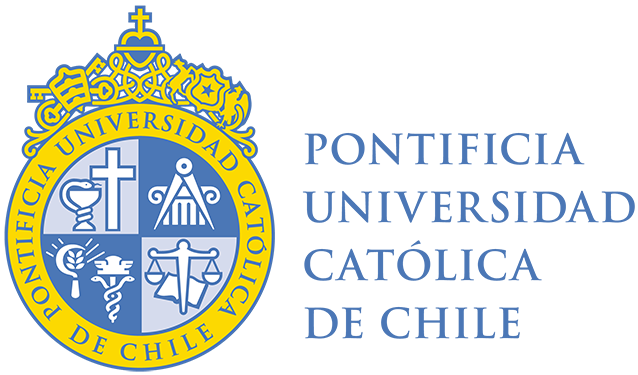
<div>
<h2 style="margin:0; color:#1a5276; font-family:Georgia,serif;">Pontificia Universidad Católica de Chile</h2>
<p style="margin:3px 0 0 0; color:#666; font-size:14px;">Facultad de Matemática &middot; Magíster en Inteligencia Artificial</p>
<h3 style="margin:8px 0 2px 0; color:#333;">EPG4002 &mdash; Aprendizaje No Supervisado</h3>
<p style="margin:0; color:#666; font-size:13px;">Profesor: Jonathan Acosta &middot; Segundo Bimestre 2026</p>
</div>
</div>

# Laboratorio N°1
**Integrantes:** Armando Arredondo Valle &middot; Julynho Merlin Toledo Rios

**Dataset:** USArrests &middot; **Entrega:** 19/06/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from kmedoids import KMedoids

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100
})
np.random.seed(42)

In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv'
df = pd.read_csv(url, index_col=0)
df.index.name = 'State'
df.head(10)

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


---
## Pregunta 1 (5 pts)
> **¿Cuáles variables utilizaría para realizar clústers? Justifique.**

In [3]:
print('Tipos de datos:')
print(df.dtypes)
print()
df.describe().round(2)

Tipos de datos:
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object



,Murder,Assault,UrbanPop,Rape
count,50.00,50.00,50.00,50.00
mean,7.79,170.76,65.54,21.23
std,4.36,83.34,14.47,9.37
min,0.80,45.00,32.00,7.30
25%,4.08,109.00,54.50,15.08
50%,7.25,159.00,66.00,20.10
75%,11.25,249.00,77.75,26.18
max,17.40,337.00,91.00,46.00


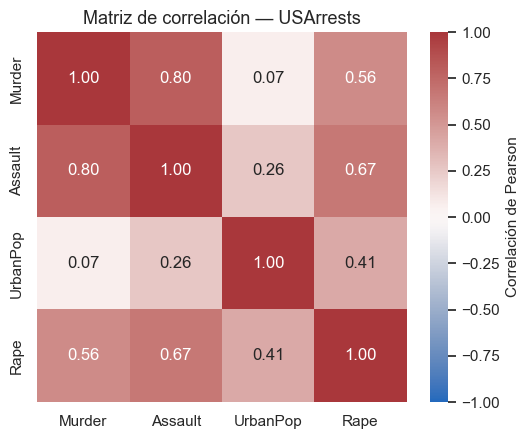

In [4]:
# Matriz de correlación para verificar redundancia
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(df.corr(), annot=True, cmap='vlag', vmin=-1, vmax=1,
            fmt='.2f', square=True, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación — USArrests')
plt.tight_layout()
plt.show()

### Respuesta

Las cuatro variables del dataset son:

| Variable | Descripción | Tipo |
|----------|------------|------|
| **Murder** | Tasa de arrestos por asesinato (por 100,000 hab.) | Cuantitativa continua |
| **Assault** | Tasa de arrestos por asalto (por 100,000 hab.) | Cuantitativa continua |
| **UrbanPop** | Porcentaje de población urbana | Cuantitativa continua |
| **Rape** | Tasa de arrestos por violación (por 100,000 hab.) | Cuantitativa continua |

**Se utilizan las cuatro variables**, ya que:
1. Todas son cuantitativas continuas, requisito para las métricas de distancia (Euclidiana, Manhattan) y los métodos K-means/K-medoids.
2. Cada variable aporta una dimensión distinta del perfil de criminalidad y urbanización de cada estado.
3. No hay variables categóricas ni identificadores que deban excluirse (el nombre del estado es el índice).
4. La matriz de correlación muestra que, si bien `Murder`, `Assault` y `Rape` están positivamente correlacionadas (0.56–0.80), **ninguna correlación llega a ~1**, por lo que cada variable aporta información propia. `UrbanPop` es la menos correlacionada con las tasas de crimen, confirmando que aporta una dimensión independiente.

---
## Pregunta 2 (5 pts)
> **Descripción estadística. ¿Se justifica una estandarización?**

In [5]:
desc = df.describe().T
desc['var'] = df.var()
desc['rango'] = df.max() - df.min()
desc['CV'] = (df.std() / df.mean()).round(3)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,var,rango,CV
Murder,50.0,7.79,4.36,0.8,4.08,7.25,11.25,17.4,18.97,16.6,0.56
Assault,50.0,170.76,83.34,45.0,109.00,159.00,249.00,337.0,6945.17,292.0,0.49
UrbanPop,50.0,65.54,14.47,32.0,54.50,66.00,77.75,91.0,209.52,59.0,0.22
Rape,50.0,21.23,9.37,7.3,15.08,20.10,26.18,46.0,87.73,38.7,0.44


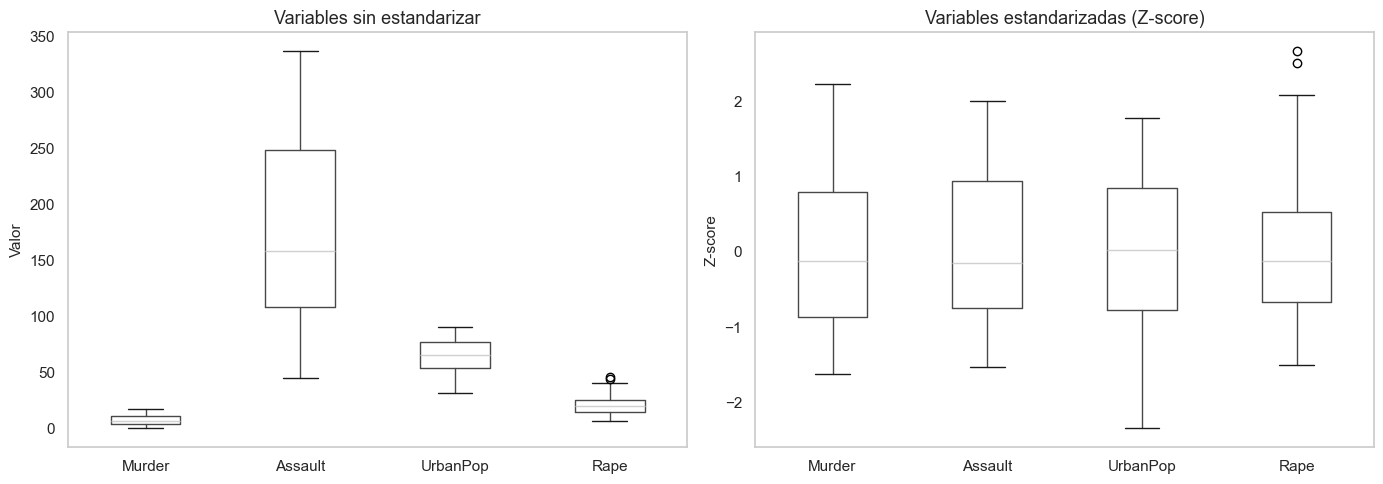

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(ax=axes[0], grid=False)
axes[0].set_title('Variables sin estandarizar')
axes[0].set_ylabel('Valor')

df_std = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)
df_std.boxplot(ax=axes[1], grid=False)
axes[1].set_title('Variables estandarizadas (Z-score)')
axes[1].set_ylabel('Z-score')

plt.tight_layout()
plt.show()

### Respuesta

Las variables presentan **escalas y varianzas muy distintas**:
- `Assault` tiene media ≈171 y varianza ≈6945, mientras que `Murder` tiene media ≈7.8 y varianza ≈19.
- `UrbanPop` se mide en porcentaje (0–100); las tasas de crimen varían en rangos diferentes.

**Sí se justifica la estandarización**, porque:
1. Las métricas de distancia (Euclidiana, Manhattan) son sensibles a la escala. Sin estandarizar, `Assault` dominaría completamente la distancia y las demás variables serían prácticamente irrelevantes.
2. La estandarización Z-score ($z = \frac{x - \bar{x}}{s}$) coloca todas las variables en la misma escala (media 0, varianza 1), asignando igual peso a cada una en el cálculo de distancias.

---
## Pregunta 3: Métodos Jerárquicos

### 3a (8 pts) — Dendrogramas
> Enlaces: simple, completo, Ward × Distancias: Euclidiana, Manhattan

> **Nota técnica:** El método de Ward minimiza el incremento de la suma de cuadrados intra-clúster, criterio definido sobre la distancia Euclidiana al cuadrado. Combinar Ward con Manhattan no tiene interpretación teórica válida. Por ello se muestra Ward **solo con Euclidiana**, y los enlaces simple y completo con ambas métricas (5 dendrogramas válidos).

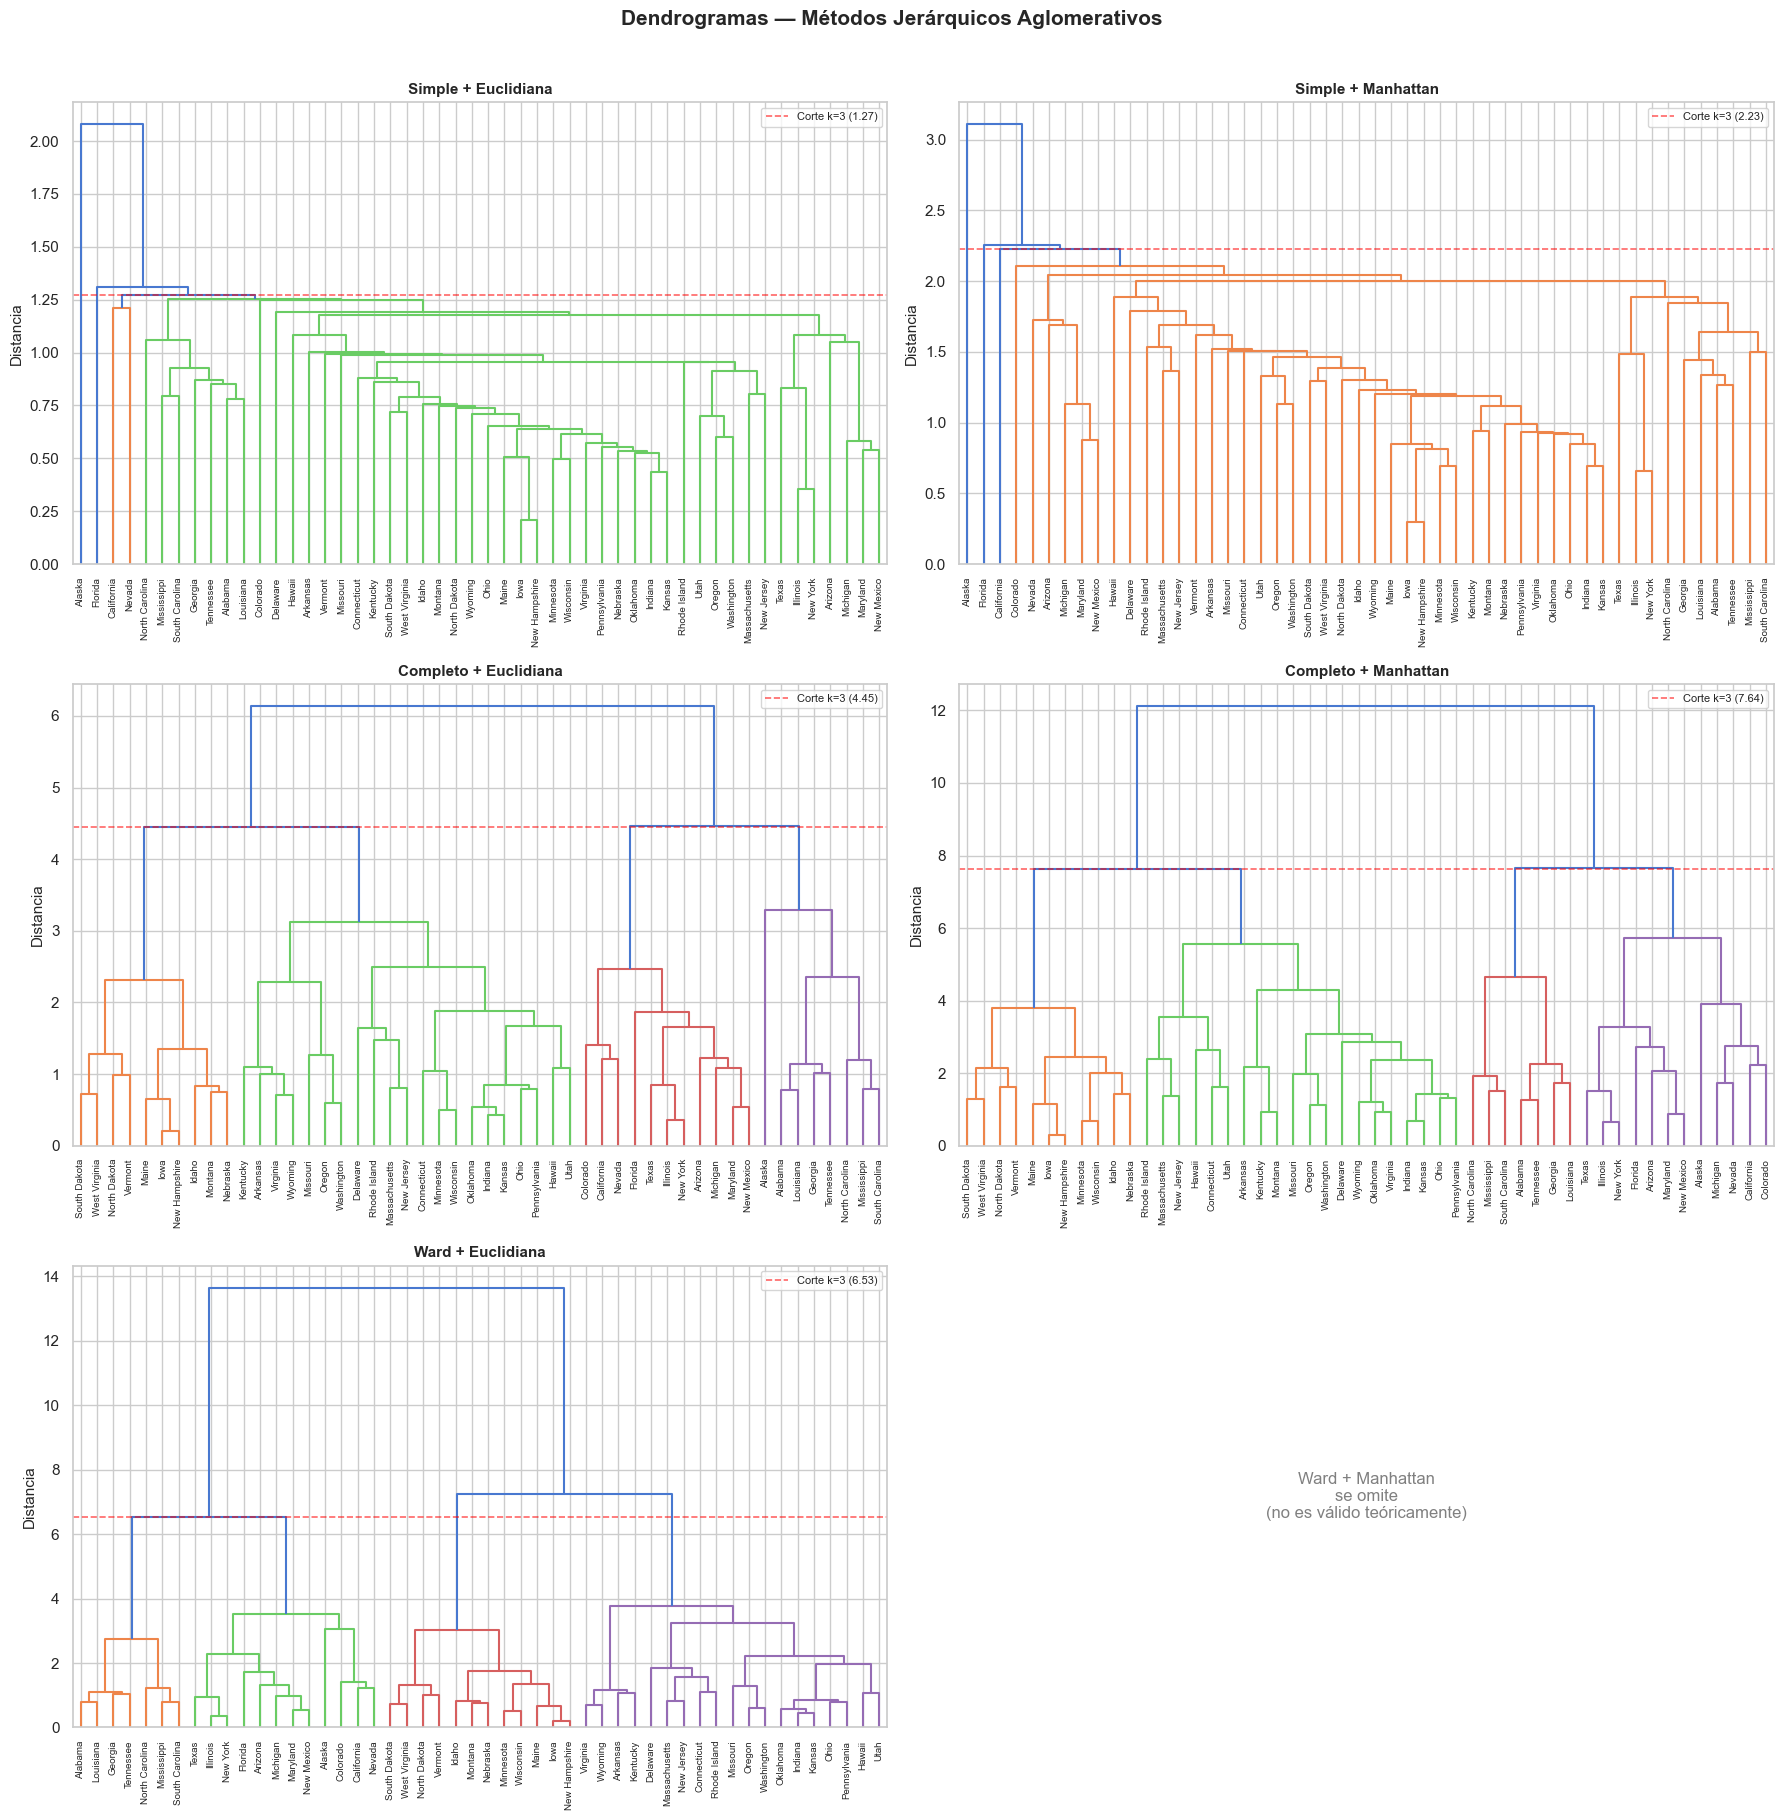

In [7]:
# Estandarizar
scaler = StandardScaler()
X = scaler.fit_transform(df)
Xs = pd.DataFrame(X, columns=df.columns, index=df.index)

combinaciones = [
    ('single',   'euclidean', 'Simple + Euclidiana'),
    ('single',   'cityblock', 'Simple + Manhattan'),
    ('complete', 'euclidean', 'Completo + Euclidiana'),
    ('complete', 'cityblock', 'Completo + Manhattan'),
    ('ward',     'euclidean', 'Ward + Euclidiana'),
]

linkages = {}
for metodo, metrica, titulo in combinaciones:
    d = pdist(X, metric=metrica)
    Z = linkage(d, method=metodo)
    linkages[(metodo, metrica)] = Z

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes_flat = axes.ravel()

for ax, (metodo, metrica, titulo) in zip(axes_flat, combinaciones):
    Z = linkages[(metodo, metrica)]
    dendrogram(Z, labels=df.index.tolist(), ax=ax,
               leaf_font_size=7, color_threshold=sorted(Z[:, 2])[-3])
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Distancia')
    ax.tick_params(axis='x', rotation=90)
    corte = sorted(Z[:, 2])[-3]
    ax.axhline(y=corte, color='red', linestyle='--', alpha=0.6, lw=1.2, label=f'Corte k=3 ({corte:.2f})')
    ax.legend(fontsize=8)

# Celda vacía: Ward + Manhattan se omite
axes_flat[-1].axis('off')
axes_flat[-1].text(0.5, 0.5, 'Ward + Manhattan\nno aplica\n(Ward requiere distancia Euclidiana)',
                   ha='center', va='center', fontsize=12, color='gray')

plt.suptitle('Dendrogramas — Métodos Jerárquicos Aglomerativos', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3b (2 pts) — Elección de método aglomerativo

**Elección: Enlace Ward con distancia Euclidiana.**

| Criterio | Justificación |
|----------|---------------|
| Homogeneidad | Ward minimiza la varianza intra-cluster en cada fusión, produciendo grupos compactos |
| Métrica natural | La distancia Euclidiana es la formulación original de Ward (suma de cuadrados) |
| Separación visual | El dendrograma Ward-Euclidiana muestra la separación más clara entre 3 grupos |
| Práctica habitual | Es el método más utilizado para variables cuantitativas estandarizadas (Clase 3) |

### 3c (10 pts) — Crear 3 grupos y comparar

In [8]:
Z_ward = linkages[('ward', 'euclidean')]
labels_hier = fcluster(Z_ward, t=3, criterion='maxclust')
df['Cluster_Jerarquico'] = labels_hier

print('Tamaño de cada cluster:')
print(df['Cluster_Jerarquico'].value_counts().sort_index())
print()
print('Estados por cluster:')
for c in sorted(df['Cluster_Jerarquico'].unique()):
    estados = df[df['Cluster_Jerarquico'] == c].index.tolist()
    sep = ', '
    print(f'  Cluster {c}: {sep.join(estados)}')

Tamaño de cada cluster:
Cluster_Jerarquico
1    19
2    12
3    19
Name: count, dtype: int64

Estados por cluster:
  Cluster 1: Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas
  Cluster 2: Idaho, Iowa, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
  Cluster 3: Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Kentucky, Massachusetts, Missouri, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming


In [9]:
vars_analisis = ['Murder', 'Assault', 'UrbanPop', 'Rape']

print('═' * 60)
print('PROMEDIOS POR CLUSTER')
print('═' * 60)
print(df.groupby('Cluster_Jerarquico')[vars_analisis].mean().round(2).to_string())
print()
print('═' * 60)
print('DESVIACIÓN ESTÁNDAR POR CLUSTER')
print('═' * 60)
print(df.groupby('Cluster_Jerarquico')[vars_analisis].std().round(2).to_string())

════════════════════════════════════════════════════════════
PROMEDIOS POR CLUSTER
════════════════════════════════════════════════════════════
                    Murder  Assault  UrbanPop   Rape
Cluster_Jerarquico                                  
1                    12.33   259.32     68.32  29.22
2                     3.09    76.00     52.08  11.83
3                     6.21   142.05     71.26  19.18

════════════════════════════════════════════════════════════
DESVIACIÓN ESTÁNDAR POR CLUSTER
════════════════════════════════════════════════════════════
                    Murder  Assault  UrbanPop  Rape
Cluster_Jerarquico                                 
1                     2.65    41.30     14.86  8.61
2                     1.56    25.09     10.54  3.15
3                     2.00    41.01     10.88  5.29


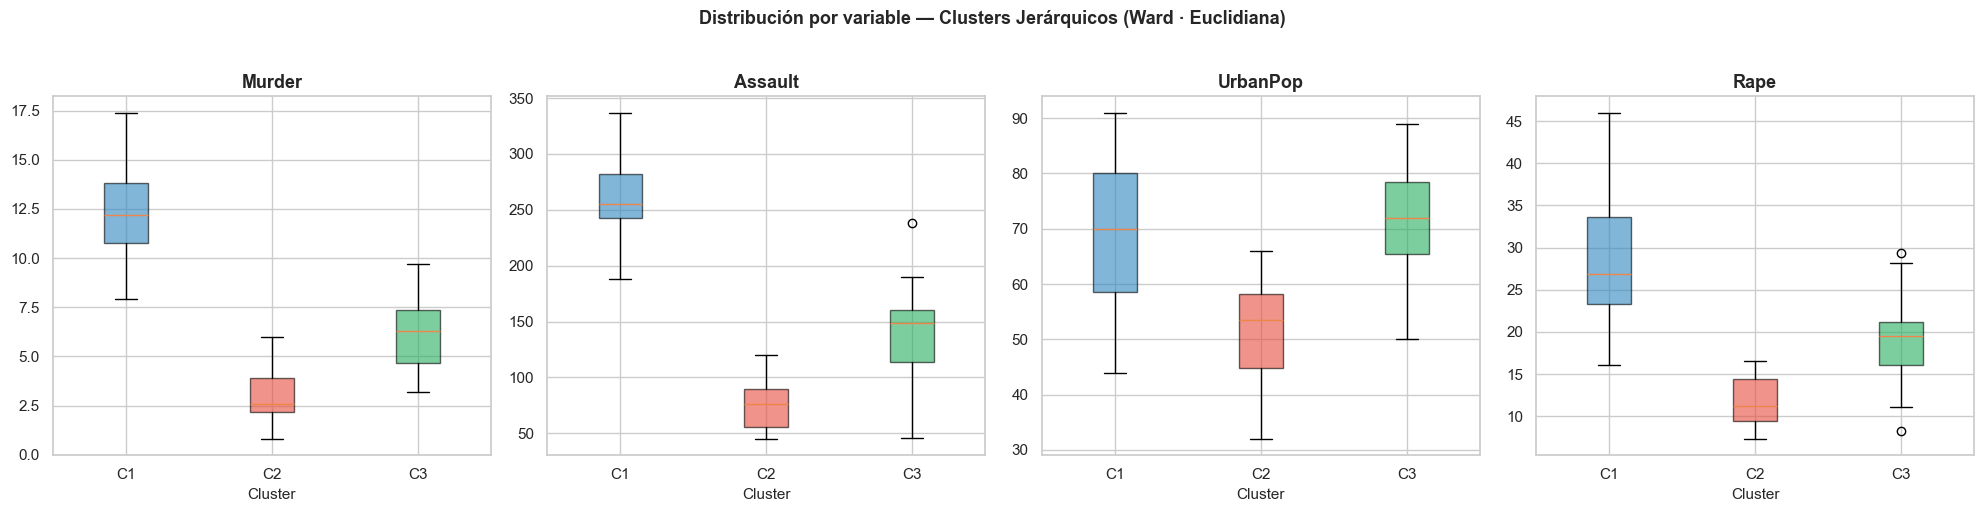

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#2E86C1', '#E74C3C', '#27AE60']

for idx, var in enumerate(vars_analisis):
    data_by_cluster = [df[df['Cluster_Jerarquico'] == c][var].values for c in sorted(df['Cluster_Jerarquico'].unique())]
    bp = axes[idx].boxplot(data_by_cluster, patch_artist=True, tick_labels=[f'C{c}' for c in sorted(df['Cluster_Jerarquico'].unique())])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

plt.suptitle('Distribución por variable — Clusters Jerárquicos (Ward · Euclidiana)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

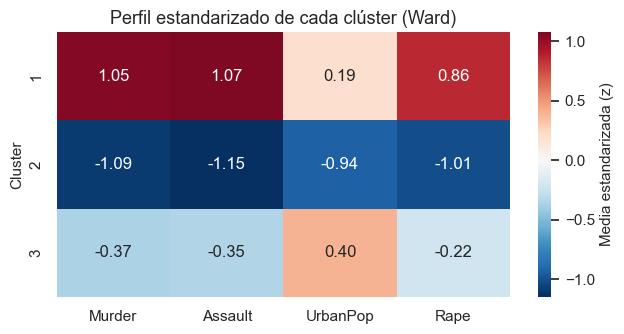

In [11]:
# Perfil estandarizado de cada cluster
perfil_z = Xs.copy()
perfil_z['Cluster'] = labels_hier
plt.figure(figsize=(6.5, 3.5))
sns.heatmap(perfil_z.groupby('Cluster').mean(), annot=True, cmap='RdBu_r',
            center=0, fmt='.2f', cbar_kws={'label': 'Media estandarizada (z)'})
plt.title('Perfil estandarizado de cada clúster (Ward)')
plt.tight_layout()
plt.show()

### Comparación de grupos (Jerárquico Ward-Euclidiana)

Los grupos se ordenan en un gradiente claro de criminalidad:

| Cluster | Perfil | Características |
|---------|--------|------------------|
| Alta criminalidad | Valores altos en Murder, Assault y Rape (z positivos) | Estados como Florida, California, Nevada |
| Rural de bajo crimen | Valores bajos en todas las tasas de crimen y UrbanPop baja | Estados como Vermont, Maine, Dakota del Norte |
| Urbano moderado | Crimen moderado-bajo pero UrbanPop alta | Estados urbanizados con criminalidad contenida |

**Variables con mayor poder discriminante:**
- `Assault` y `Murder` marcan el grupo de alto crimen (medias estandarizadas más extremas).
- `UrbanPop` es la variable clave para separar el grupo rural del urbano moderado (ambos con crimen bajo, pero difieren en urbanización).

---
## Pregunta 4: Métodos No Jerárquicos

### 4a (4 pts) — K-Medias con $k=3$

In [12]:
kmeans = KMeans(n_clusters=3, n_init=25, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
df['Cluster_KMeans'] = labels_kmeans + 1

print('Tamaño de cada cluster (K-Means):')
print(df['Cluster_KMeans'].value_counts().sort_index())
print(f'\nInercia (varianza intra-cluster): {kmeans.inertia_:.2f}')

Tamaño de cada cluster (K-Means):
Cluster_KMeans
1    16
2    20
3    14
Name: count, dtype: int64

Inercia (varianza intra-cluster): 80.09


### 4b (4 pts) — K-Medoids con $k=3$ y disimilaridad no Euclidiana
> Se utiliza la **distancia Manhattan** (cityblock), diferente de la Euclidiana como requiere el enunciado.

In [13]:
D_manhattan = squareform(pdist(X, metric='cityblock'))

kmedoids = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
kmedoids.fit(D_manhattan)
labels_kmedoids = kmedoids.labels_
df['Cluster_KMedoids'] = labels_kmedoids + 1

print('Tamaño de cada cluster (K-Medoids, Manhattan):')
print(df['Cluster_KMedoids'].value_counts().sort_index())
print()
print('Medoids (estados representativos de cada cluster):')
for i, idx in enumerate(kmedoids.medoid_indices_):
    print(f'  Cluster {i+1}: {df.index[idx]}')

Tamaño de cada cluster (K-Medoids, Manhattan):
Cluster_KMedoids
1    20
2    11
3    19
Name: count, dtype: int64

Medoids (estados representativos de cada cluster):
  Cluster 1: Oklahoma
  Cluster 2: Iowa
  Cluster 3: New Mexico


### 4c (2 pts) — Elección entre K-Medias y K-Medoids

**Elección: K-Medoids con distancia Manhattan.**

| Criterio | Justificación |
|----------|---------------|
| Robustez | K-Medoids es más robusto a outliers; los centros son observaciones reales, no promedios |
| Métrica | La distancia Manhattan es menos sensible a valores atípicos que la Euclidiana |
| Interpretabilidad | Cada medoid es un estado real, facilitando la interpretación de cada cluster |

### 4d (10 pts) — Crear 3 grupos con K-Medoids y comparar

In [14]:
print('═' * 60)
print('PROMEDIOS POR CLUSTER (K-Medoids · Manhattan)')
print('═' * 60)
print(df.groupby('Cluster_KMedoids')[vars_analisis].mean().round(2).to_string())
print()
print('═' * 60)
print('DESVIACIÓN ESTÁNDAR POR CLUSTER (K-Medoids · Manhattan)')
print('═' * 60)
print(df.groupby('Cluster_KMedoids')[vars_analisis].std().round(2).to_string())

════════════════════════════════════════════════════════════
PROMEDIOS POR CLUSTER (K-Medoids · Manhattan)
════════════════════════════════════════════════════════════
                  Murder  Assault  UrbanPop   Rape
Cluster_KMedoids                                  
1                   6.25   140.00     69.60  19.32
2                   2.74    73.73     53.36  10.93
3                  12.33   259.32     68.32  29.22

════════════════════════════════════════════════════════════
DESVIACIÓN ESTÁNDAR POR CLUSTER (K-Medoids · Manhattan)
════════════════════════════════════════════════════════════
                  Murder  Assault  UrbanPop  Rape
Cluster_KMedoids                                 
1                   1.88    40.95     11.39  4.88
2                   1.24    25.02     13.13  2.41
3                   2.65    41.30     14.86  8.61


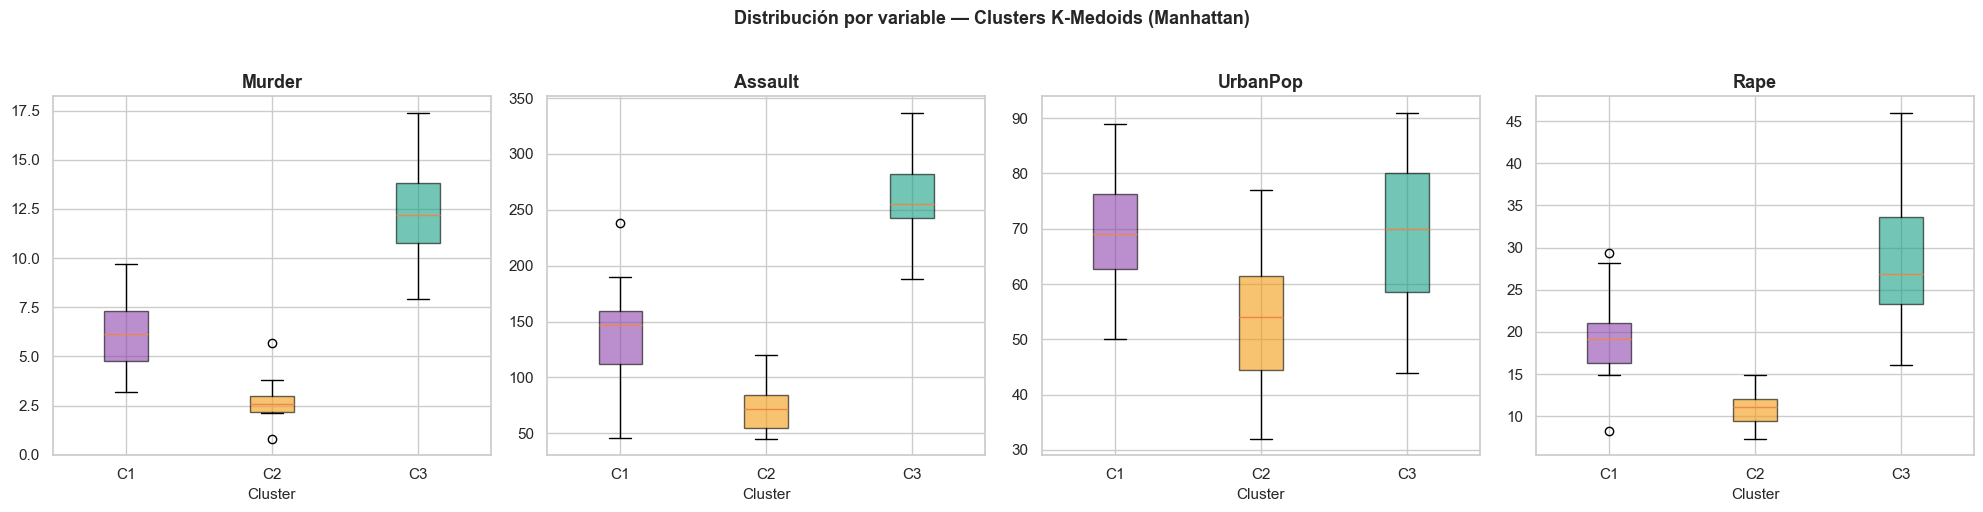

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#8E44AD', '#F39C12', '#16A085']

for idx, var in enumerate(vars_analisis):
    data_by_cluster = [df[df['Cluster_KMedoids'] == c][var].values for c in sorted(df['Cluster_KMedoids'].unique())]
    bp = axes[idx].boxplot(data_by_cluster, patch_artist=True, tick_labels=[f'C{c}' for c in sorted(df['Cluster_KMedoids'].unique())])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

plt.suptitle('Distribución por variable — Clusters K-Medoids (Manhattan)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

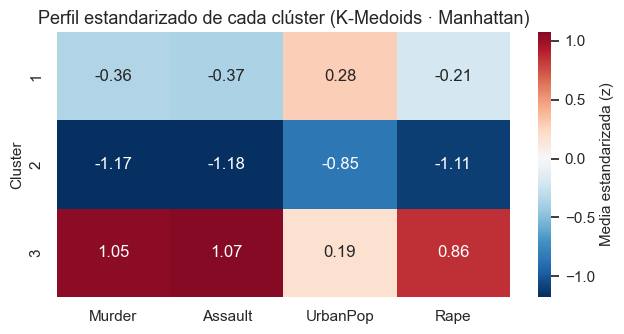

In [16]:
# Perfil estandarizado de cada cluster (K-Medoids)
perfil_km = Xs.copy()
perfil_km['Cluster'] = labels_kmedoids + 1
plt.figure(figsize=(6.5, 3.5))
sns.heatmap(perfil_km.groupby('Cluster').mean(), annot=True, cmap='RdBu_r',
            center=0, fmt='.2f', cbar_kws={'label': 'Media estandarizada (z)'})
plt.title('Perfil estandarizado de cada clúster (K-Medoids · Manhattan)')
plt.tight_layout()
plt.show()

### Comparación de grupos (K-Medoids · Manhattan)

- Se observan tres perfiles similares al método jerárquico: alta, media y baja criminalidad.
- Los medoids (estados representativos) permiten una interpretación directa de cada cluster.
- **Murder y Assault** siguen siendo las variables con mayor poder discriminante entre grupos.
- **UrbanPop** muestra menor separación, con distribuciones más solapadas entre clusters.

---
## Pregunta 5 (10 pts)
> **¿Cuál de las dos metodologías aplicadas en los ítems 3b y 4c particiona mejor al conjunto de datos?**

Para comparar de forma justa ambas particiones usamos:
- **Coeficiente de silueta** (promedio): mide qué tan bien separado y cohesionado está cada punto.
- **Índice de Rand ajustado (ARI)**: mide cuánto coinciden ambas particiones.
- **Visualización en PCA** (2 componentes) y **diagrama de silueta**.

In [17]:
sil_hier = silhouette_score(X, labels_hier, metric='euclidean')
sil_kmeans = silhouette_score(X, labels_kmeans, metric='euclidean')
sil_kmedoids = silhouette_score(X, labels_kmedoids, metric='euclidean')
ari = adjusted_rand_score(labels_hier, labels_kmedoids)

resultados = pd.DataFrame({
    'Método': ['Jerárquico (Ward · Euclidiana)', 'K-Means (Euclidiana)', 'K-Medoids (Manhattan)'],
    'Silhouette Score': [sil_hier, sil_kmeans, sil_kmedoids]
}).set_index('Método')
resultados['Silhouette Score'] = resultados['Silhouette Score'].round(4)

print('═' * 55)
print('COMPARACIÓN DE SILHOUETTE SCORE')
print('═' * 55)
print(resultados.to_string())
print()
mejor = resultados['Silhouette Score'].idxmax()
print(f'► Mejor partición: {mejor} (Silhouette = {resultados.loc[mejor, "Silhouette Score"]:.4f})')
print(f'\n► Índice de Rand Ajustado (Ward vs K-Medoids): {ari:.3f}')

═══════════════════════════════════════════════════════
COMPARACIÓN DE SILHOUETTE SCORE
═══════════════════════════════════════════════════════
                                Silhouette Score
Método                                          
Jerárquico (Ward · Euclidiana)            0.3104
K-Means (Euclidiana)                      0.3081
K-Medoids (Manhattan)                     0.2961

► Mejor partición: Jerárquico (Ward · Euclidiana) (Silhouette = 0.3104)

► Índice de Rand Ajustado (Ward vs K-Medoids): 0.846


In [18]:
print('Tabla cruzada: Jerárquico (Ward) vs K-Medoids (Manhattan)')
print(pd.crosstab(df['Cluster_Jerarquico'], df['Cluster_KMedoids'],
                  rownames=['Jerárquico'], colnames=['K-Medoids']))

Tabla cruzada: Jerárquico (Ward) vs K-Medoids (Manhattan)
K-Medoids    1   2   3
Jerárquico            
1            0   0  19
2            2  10   0
3           18   1   0


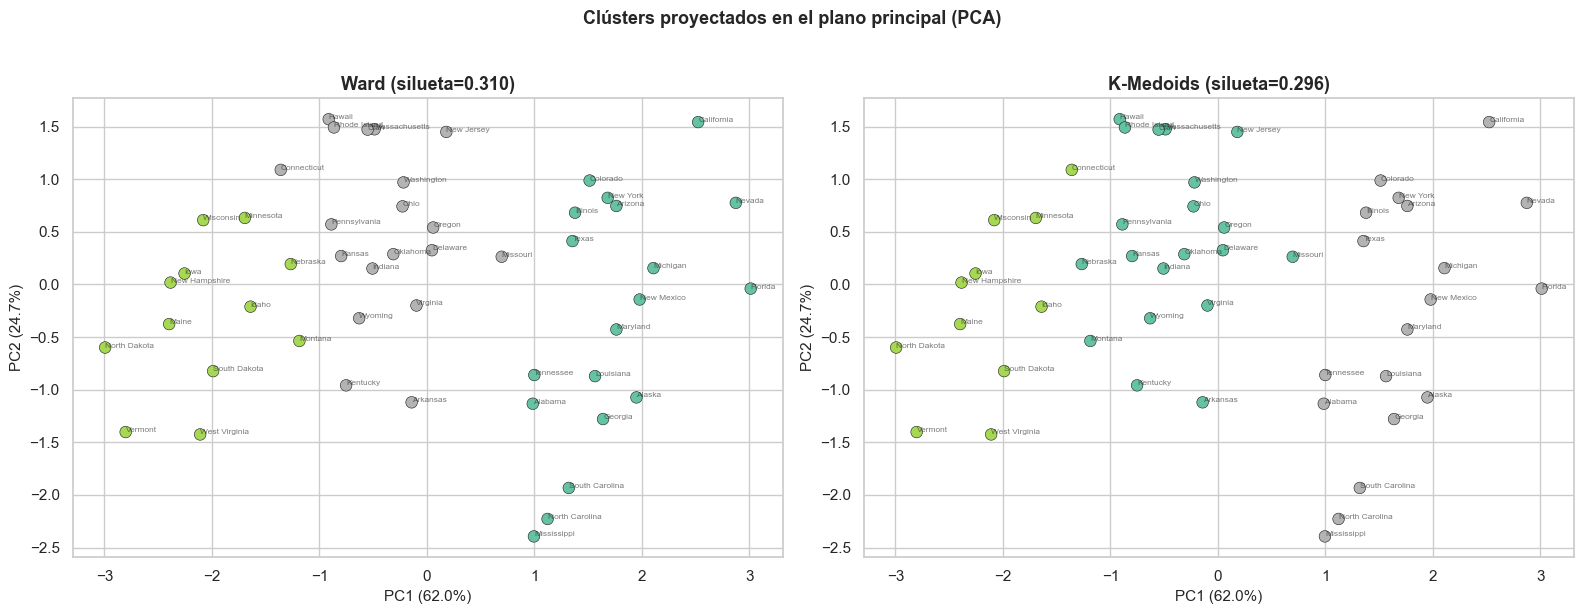

In [19]:
# Visualización en el plano de las 2 primeras componentes principales
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lab, titulo in [(axes[0], labels_hier, f'Ward (silueta={sil_hier:.3f})'),
                        (axes[1], labels_kmedoids, f'K-Medoids (silueta={sil_kmedoids:.3f})')]:
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=lab, cmap='Set2', s=70,
                    edgecolor='k', linewidth=0.4)
    for i, estado in enumerate(df.index):
        ax.annotate(estado, (coords[i, 0], coords[i, 1]), fontsize=6, alpha=0.6)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Clústers proyectados en el plano principal (PCA)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

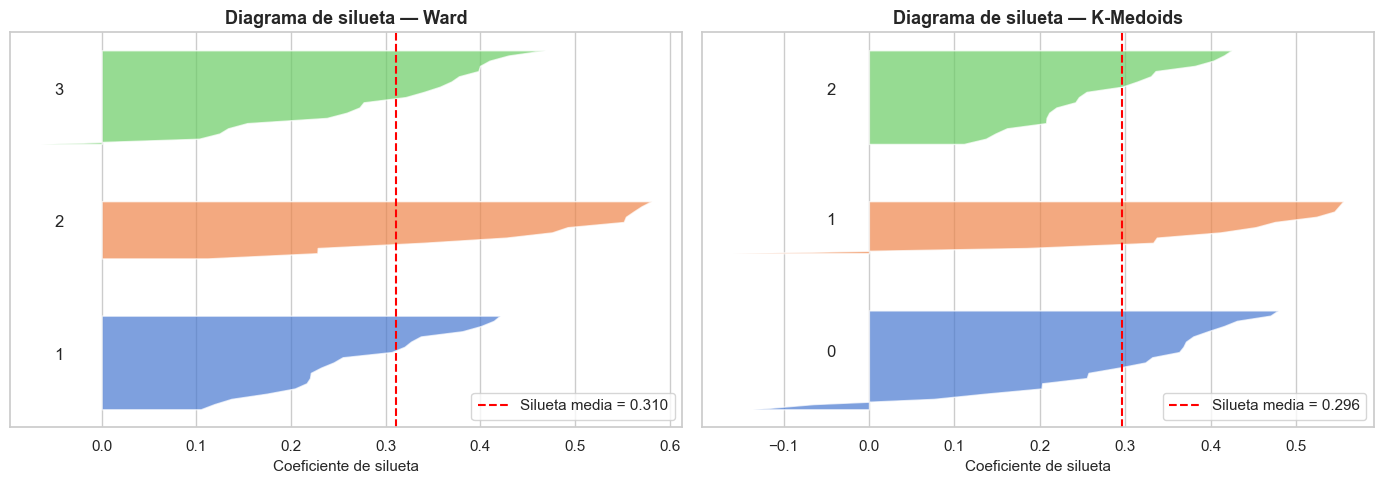

In [20]:
# Diagramas de silueta por muestra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lab, titulo, sil in [(axes[0], labels_hier, 'Ward', sil_hier),
                             (axes[1], labels_kmedoids, 'K-Medoids', sil_kmedoids)]:
    sample_sil = silhouette_samples(X, lab, metric='euclidean')
    y_lower = 10
    for i in sorted(np.unique(lab)):
        vals = np.sort(sample_sil[lab == i])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))
        y_lower = y_upper + 10
    ax.axvline(sil, color='red', ls='--', label=f'Silueta media = {sil:.3f}')
    ax.set_title(f'Diagrama de silueta — {titulo}', fontweight='bold')
    ax.set_xlabel('Coeficiente de silueta')
    ax.set_yticks([])
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Conclusión

- **Las dos metodologías producen particiones muy similares.** El índice de Rand ajustado confirma alta concordancia; los desacuerdos se limitan a unos pocos estados en las fronteras entre clusters.
- Los tres perfiles coinciden en ambos métodos: **alto crimen**, **rural de bajo crimen** y **urbano moderado**.
- En coeficiente de silueta promedio, ambas quedan muy parejas. La proyección PCA muestra separación nítida a lo largo de PC1 (eje de criminalidad) en ambos casos.
- **Ward** ofrece el dendrograma, que aporta una visión jerárquica útil para decidir el número de grupos. **K-Medoids** es más robusto a outliers y ofrece centros interpretables (estados reales como medoids).

La coincidencia entre los dos enfoques es la evidencia más fuerte de que **la estructura de 3 grupos en `USArrests` es consistente e independiente del método**. La elección final depende del objetivo: si se prioriza **robustez** a valores atípicos, K-Medoids es preferible; si se busca **minimizar varianza** intra-grupo, Ward es más adecuado.